In [1]:
import pickle
import glob
import numpy as np
import matplotlib.pyplot as plt

files = sorted(glob.glob(
    "results/results_UI_2DLQR_constrained_forgetting_factor_0_03_baseline_0_03_*.pickle"
))

print("Loaded files:", len(files))
for f in files:
    print(f)

trials = []
for f in files:
    with open(f, "rb") as handle:
        trials.append(pickle.load(handle))

Loaded files: 9
results/results_UI_2DLQR_constrained_forgetting_factor_0_03_baseline_0_03_1.pickle
results/results_UI_2DLQR_constrained_forgetting_factor_0_03_baseline_0_03_2.pickle
results/results_UI_2DLQR_constrained_forgetting_factor_0_03_baseline_0_03_3.pickle
results/results_UI_2DLQR_constrained_forgetting_factor_0_03_baseline_0_03_4.pickle
results/results_UI_2DLQR_constrained_forgetting_factor_0_03_baseline_0_03_5.pickle
results/results_UI_2DLQR_constrained_forgetting_factor_0_03_baseline_0_03_6.pickle
results/results_UI_2DLQR_constrained_forgetting_factor_0_03_baseline_0_03_7.pickle
results/results_UI_2DLQR_constrained_forgetting_factor_0_03_baseline_0_03_8.pickle
results/results_UI_2DLQR_constrained_forgetting_factor_0_03_baseline_0_03_9.pickle


n_trials: 9
Final mean: 1.4775167
Final std: 0.30092475
Unstable mean: 0.0
Unstable std: 0.0


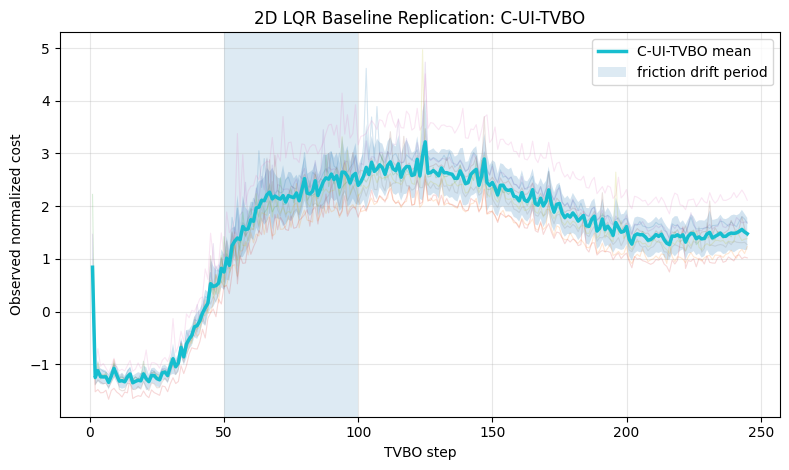

In [5]:
def get_curve(data, n_initial=30):
    f = np.asarray(data["f_of_x"]).reshape(-1)
    return f[n_initial:]

def count_unstable(data, n_initial=30):
    stable = data["stable"]
    return sum(1 for s in stable[n_initial:] if not s)

curves = [get_curve(d, n_initial=30) for d in trials]

min_len = min(len(c) for c in curves)
curves = np.array([c[:min_len] for c in curves])

mean_curve = curves.mean(axis=0)
std_curve = curves.std(axis=0)
t = np.arange(1, min_len + 1)

unstables = [count_unstable(d, n_initial=30) for d in trials]

print("n_trials:", len(trials))
print("Final mean:", mean_curve[-1])
print("Final std:", std_curve[-1])
print("Unstable mean:", np.mean(unstables))
print("Unstable std:", np.std(unstables))

plt.figure(figsize=(8, 4.8))

for c in curves:
    plt.plot(t, c, alpha=0.18, linewidth=0.8)

plt.plot(t, mean_curve, linewidth=2.5, label="C-UI-TVBO mean")
plt.fill_between(t, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)

plt.axvspan(50, 100, alpha=0.15, label="friction drift period")
plt.xlabel("TVBO step")
plt.ylabel("Observed normalized cost")
plt.title("2D LQR Baseline Replication: C-UI-TVBO")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/cui_baseline_9trials.png", dpi=300)
plt.savefig("results/cui_baseline_9trials.png", dpi=300, bbox_inches="tight")
plt.show()